# Numerical Simulation Laboratory (NSL) 
## Numerical exercises 3

### Exercise 03.1 Plain vanilla option pricing 

Black-Scholes theory assumes that the time evolution of the asset price is stochastic and exhibits geometric Brownian motion (GBM) with constant risk-free interest rate $r$ and volatility $\sigma$.

Black-Scholes analytic solution  for the price at time t<T:
- European Call-option price:
$$ C\left[ S(t),t \right] = S(t) N(d_1) -K e^{-r(T-t)} N(d_2) $$
- European Put-option price:
$$ P\left[ S(t),t \right] = S(t) \left[ N(d_1)-1\right] -K e^{-r(T-t)} \left[ N(d_2)-1\right]$$

where 
$$d_1 = \frac{1}{\sigma\sqrt{T-t}}\left[ \ln \left( \frac{S(t)}{K} \right) + \left( r+\frac{\sigma^2}{2} (T-t) \right)\right]$$

where $d_2 = d_1 - \sigma\sqrt{T-t}$, and where
$$ N(x) = \int_{-\infty}^{x} dz \, e^{-\frac{z^2}{2}} = \frac{1}{2} \left[ 1+ {\rm erf} \left( \frac{x}{\sqrt{2}}\right) \right]$$
is the cumulative of Gaussian $\sim \mathcal{N}(\mu=0,\sigma^2=1)$,
and where
$${\rm erf}(x) = \frac{2}{\sqrt{\pi}}\int_{0}^{x} dz \, e^{-z^2}$$

By using the following parameters: 
- asset price at $t=0$: $S(0)=100$
- delivery time: $T=1$
- strike price: $K=100$
- risk-free interest rate: $r=0.1$
- volatility: $\sigma=0.25$

compute at time $t=0$ **via Monte Carlo** the European call-option price, $C[S(0),0]$, and put-option price, $P[S(0),0]$:

1. By sampling **directly** the final asset price $S(T)$ for a $GBM(r,\sigma^2)$
2. By sampling the discretized $GBM(r,\sigma^2)$ path of the asset price 
dividing $[0,T]$ in $10^2$ time intervals: $S(0)$, $S(t_1)$, $S(t_2)$, ... up to $S(t_{100}=T=1)$

    Remember that given an asset price $S\sim GBM(\mu,\sigma^2)$, with initial value $S(0)$, then
    $$S(t) = S(0) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)t+\sigma W(t)\right]$$
    where $W(t)\sim\mathcal{N}(0,t)$.
    Moreover, since the increments of $W$ are independent and normally distributed, the simple recursive procedure for sampling discretized values of $S\sim GBM(\mu,\sigma^2)$ at $t_1 < t_2 < … < t_n$ is:
$$S(t_{i+1}) = S(t_i) \exp\left[ \left(\mu-\frac{1}{2}\sigma^2\right)(t_{i+1}-t_i)
    +\sigma Z_{i+1}\sqrt{t_{i+1}-t_i}\right]$$
   
with $Z_i \sim \mathcal{N}(0,1)$

Make four pictures for the estimation of the European call-option prices, $C[S(0),0]$ (direct and discretized), and put-option prices, $P[S(0),0]$ (direct and discretized), with their uncertainties with a large number of asset prices at time $t=T$, say $M\ge 10^4$, as a function of the number of blocks, $N$. As usual, in computing statistical uncertainties, use data blocking.

In [1]:
import scipy
import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import numpy as np
import matplotlib.gridspec as gridspec

from scipy.stats import norm
from scipy.optimize import curve_fit
from scipy.special import erf
from mpl_toolkits.mplot3d.art3d import Line3DCollection
from numpy import exp
from numpy.lib.scimath import log, sqrt

plt.style.use('default')
mpl.rcParams['font.size'] = 10
mpl.rcParams['axes.labelsize'] = 12
mpl.rcParams['axes.titlesize'] = 16
mpl.rcParams['legend.fontsize'] = 10
mpl.rcParams['lines.linewidth'] = 2
mpl.rcParams['lines.markersize'] = 6

color=plt.cm.inferno(0.5)
color2=plt.cm.inferno(0.2)

### Implementation

#### European Call and Put Option Prices Calculation
Il file main.cpp implementa un programma in C++ per stimare i prezzi delle opzioni europee call e put utilizzando il metodo Monte Carlo. Il programma calcola i prezzi delle opzioni in due modi distinti:

- Metodo Direct: Calcolo diretto del prezzo finale dell'asset ( $S(T)$ ) utilizzando la formula analitica del moto browniano geometrico.

- Metodo Discretized: Calcolo del prezzo finale dell'asset ( $S(T)$ ) simulando il percorso discreto dell'asset in ( $N$ ) intervalli temporali.

#### Parametri del Problema
Il programma utilizza i seguenti parametri per il calcolo:

- ( $S_0 = 100$ ): Prezzo iniziale dell'asset.
- ( $K = 100$ ): Prezzo di esercizio (strike price).
- ( $T = 1$ ): Tempo di consegna (delivery time).
- ( $r = 0.1$ ): Tasso di interesse privo di rischio.
- ( $\sigma = 0.25$ ): Volatilità dell'asset.
- ( $M = 100,000$ ): Numero totale di simulazioni Monte Carlo.
- ( $N = 100$ ): Numero di blocchi per il data blocking.
- ( $L = M / N$ ): Numero di simulazioni per ciascun blocco.

#### Metodo Direct
Nel metodo direct, il programma calcola direttamente il prezzo finale dell'asset ( $S(T)$ ) utilizzando la formula analitica del moto browniano geometrico. Per ogni simulazione:

Viene generato un numero casuale ( $Z \sim \mathcal{N}(0, 1)$ ).
Si calcola ( $S(T)$ ) utilizzando la funzione $S(S0, r, sigma, Z, T)$.
Si calcolano i prezzi delle opzioni call e put utilizzando le funzioni $C$ e $P$.
Il risultato viene accumulato per ciascun blocco e viene calcolata la media e l'errore statistico.

#### Metodo Discretized
Nel metodo discretized, il programma simula il percorso discreto dell'asset dividendo l'intervallo temporale ( $[0, T]$ ) in ( $100$ ) sottointervalli. Per ogni simulazione:

Si parte da ( $S(0) = S_0$ ).
Per ciascun intervallo temporale ( $\Delta t = T / 100$ ), si calcola il valore dell'asset ( $S(t_{i+1})$ ) utilizzando la formula:
$$S(t_{i+1}) = S(t_i) \cdot \exp\left[\left(r - \frac{1}{2}\sigma^2\right)\Delta t + \sigma Z \sqrt{\Delta t}\right] \, ,$$ 
dove ( $Z \sim \mathcal{N}(0, 1)$ ) è un numero casuale.
Dopo aver calcolato ( $S(T)$ ), si calcolano i prezzi delle opzioni call e put utilizzando le funzioni $C$ e $P$.
Anche in questo caso, il risultato viene accumulato per ciascun blocco e viene calcolata la media e l'errore statistico.

#### Data Blocking
Il programma utilizza il metodo del data blocking per stimare la media e l'errore statistico dei prezzi delle opzioni:

I risultati delle simulazioni vengono suddivisi in ( $N$ ) blocchi.
Per ciascun blocco, vengono calcolate la media e la varianza dei prezzi delle opzioni.
Viene calcolato l'errore statistico utilizzando la funzione error.

#### Output
Il programma salva i risultati in quattro file:

1. out_call.data: Prezzi medi e errori delle call option calcolati con il metodo direct.
2. out_put.data: Prezzi medi e errori delle put option calcolati con il metodo direct.
3. out_call_disc.data: Prezzi medi e errori delle call option calcolati con il metodo discretized.
4. out_put_disc.data: Prezzi medi e errori delle put option calcolati con il metodo discretized.
Ogni file contiene tre colonne:

Numero di simulazioni.
Prezzo medio.
Errore statistico.

### Comparison
In the following code cell, there's a python script which computes the analytic solution of the Black & Scholes theory. We are using it for comparison.

In [2]:
# data
S0 = 100.
K = 100.
T = 1.
r = 0.1
sigma = 0.25
t=0

def N(x):
    return 0.5 * (1. + erf(x / sqrt(2.)))

def black_scholes(S0, K, T, r, sigma):
    d1 = 1./(sigma * sqrt(T)) * (log(S0 / K) + (r + (sigma**2) / 2.) * T)
    d2 = d1 - sigma * sqrt(T)
    C = S0 * N(d1) - K * exp(-r * T) * N(d2)
    P = S0 *(N(d1) - 1.) - K * exp(-r * T) * (N(d2)-1.)
    return C, P

if __name__ == "__main__":
    call, put = black_scholes(S0, K, T, r, sigma)
    print(" == BLACK-SCHOLES ==")
    print("call: ", call)
    print("put: ", put)

 == BLACK-SCHOLES ==
call:  14.975790778311286
put:  5.4595325819072364


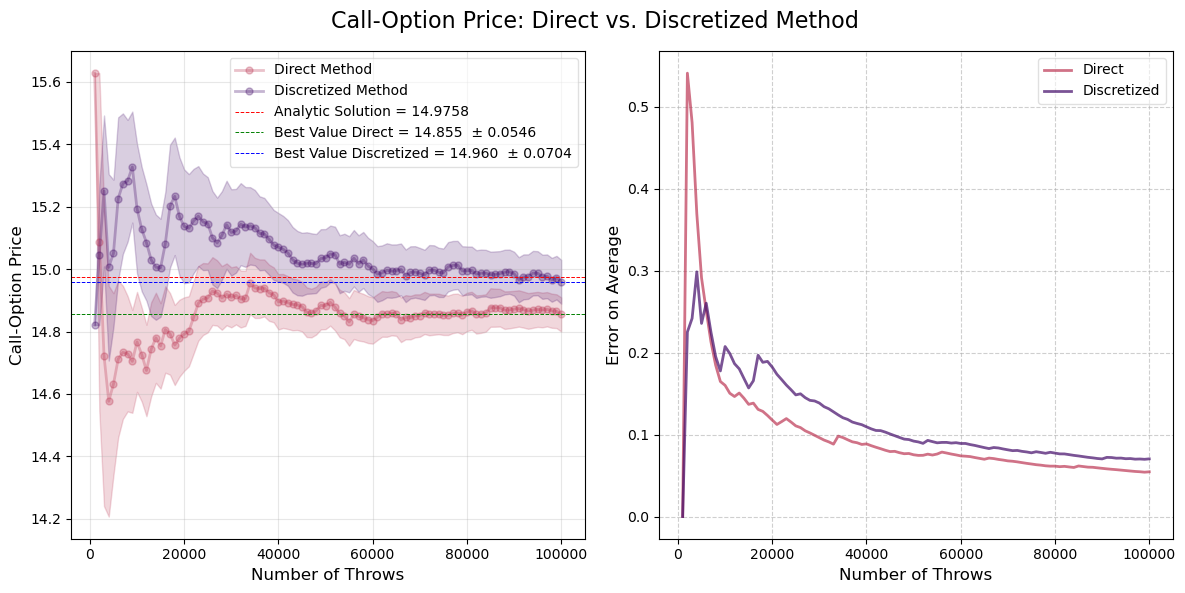

In [14]:
# Call Anlayis
avg= "ex03.1/out_call.data"
avg_disc = "ex03.1/out_call_disc.data"
x1, y1, error1 = np.loadtxt(avg, usecols=(0,1,2), delimiter='\t', unpack=True)
x2, y2, error2 = np.loadtxt(avg_disc, usecols=(0,1,2), delimiter='\t', unpack=True)

x3, y3 = np.loadtxt(avg, usecols=(0,2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(avg_disc, usecols=(0,2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Average 
ax[0].plot(x1, y1, 'o-', color=color, alpha=0.3, markersize=5, label='Direct Method')
ax[0].fill_between(x1, y1-error1, y1+error1, color=color, alpha=0.2)
ax[0].plot(x2, y2, 'o-', color=color2, alpha=0.3, markersize=5, label='Discretized Method')
ax[0].fill_between(x2, y2-error2, y2+error2, color=color2, alpha=0.2)
ax[0].axhline(y=call, color='red', linestyle='--', linewidth=0.7, label=rf'Analytic Solution = {call:.4f}')
ax[0].axhline(y=y1[99], color='green', linestyle='--', linewidth=0.7, label=f'Best Value Direct = {y1[99]:.3f}  ± {error1[99]:.4f}')
ax[0].axhline(y=y2[99], color='blue', linestyle='--', linewidth=0.7, label=f'Best Value Discretized = {y2[99]:.3f}  ± {error2[99]:.4f}')
ax[0].set_xlabel('Number of Throws')
ax[0].set_ylabel('Call-Option Price')
ax[0].legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', fontsize=10, framealpha=0.6)
ax[0].grid(alpha=0.3)
ax[0].tick_params(axis='x')

# Plot 2: Error on Average
ax[1].plot(x3, y3, color=color, alpha=0.7, label='Direct')
ax[1].plot(x4, y4, color=color2, alpha=0.7, label='Discretized')
ax[1].set_xlabel('Number of Throws')
ax[1].set_ylabel('Error on Average')
ax[1].grid(True, alpha=0.6, linestyle='--')
ax[1].legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', fontsize=10, framealpha=0.6)

fig.suptitle('Call-Option Price: Direct vs. Discretized Method', fontsize=16)

plt.tight_layout()
plt.show()

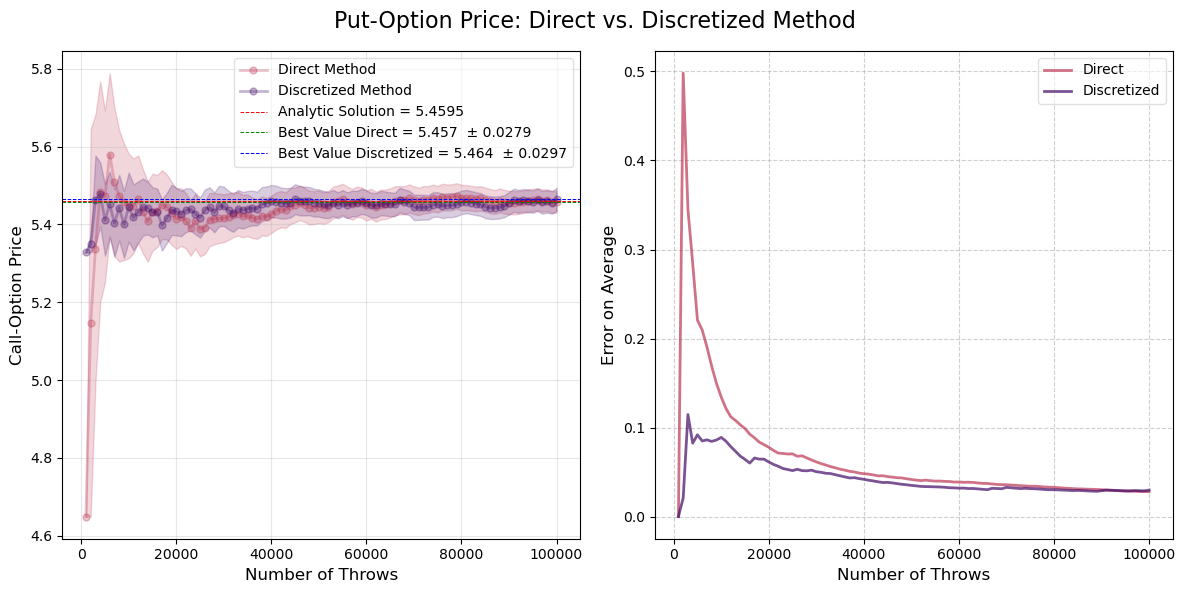

In [13]:
# Put Anlayis
avg= "ex03.1/out_put.data"
avg_disc = "ex03.1/out_put_disc.data"
x1, y1, error1 = np.loadtxt(avg, usecols=(0,1,2), delimiter='\t', unpack=True)
x2, y2, error2 = np.loadtxt(avg_disc, usecols=(0,1,2), delimiter='\t', unpack=True)

x3, y3 = np.loadtxt(avg, usecols=(0,2), delimiter='\t', unpack=True)
x4, y4 = np.loadtxt(avg_disc, usecols=(0,2), delimiter='\t', unpack=True)

fig, ax = plt.subplots(1, 2, figsize=(12, 6))

# Plot 1: Average 
ax[0].plot(x1, y1, 'o-', color=color, alpha=0.3, markersize=5, label='Direct Method')
ax[0].fill_between(x1, y1-error1, y1+error1, color=color, alpha=0.2)
ax[0].plot(x2, y2, 'o-', color=color2, alpha=0.3, markersize=5, label='Discretized Method')
ax[0].fill_between(x2, y2-error2, y2+error2, color=color2, alpha=0.2)
ax[0].axhline(y=put, color='red', linestyle='--', linewidth=0.7, label=rf'Analytic Solution = {put:.4f}')
ax[0].axhline(y=y1[99], color='green', linestyle='--', linewidth=0.7, label=f'Best Value Direct = {y1[99]:.3f}  ± {error1[99]:.4f}')
ax[0].axhline(y=y2[99], color='blue', linestyle='--', linewidth=0.7, label=f'Best Value Discretized = {y2[99]:.3f}  ± {error2[99]:.4f}')
ax[0].set_xlabel('Number of Throws')
ax[0].set_ylabel('Call-Option Price')
ax[0].legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', fontsize=10, framealpha=0.6)
ax[0].grid(alpha=0.3)
ax[0].tick_params(axis='x')

# Plot 2: Error on Average
ax[1].plot(x3, y3, color=color, alpha=0.7, label='Direct')
ax[1].plot(x4, y4, color=color2, alpha=0.7, label='Discretized')
ax[1].set_xlabel('Number of Throws')
ax[1].set_ylabel('Error on Average')
ax[1].grid(True, alpha=0.6, linestyle='--')
ax[1].legend(loc='upper right', frameon=True, fancybox=True, facecolor='white', fontsize=10, framealpha=0.6)

fig.suptitle('Put-Option Price: Direct vs. Discretized Method', fontsize=16)

plt.tight_layout()
plt.show()